In [1]:
from helpers import *
import numpy as np
from implementations import *
from helpers import pca_reduction

keep_columns = [
    "_AGEG5YR", "_AGE65YR", "_AGE80", "_BMI5CAT", "_RFBMI5", "_CHLDCNT", "_EDUCAG", "_INCOMG",
    "_SMOKER3", "_RFSMOK3", "DRNKANY5", "DROCDY3_", "_RFBING5", "_RFDRHV5", "_PAINDX1",
    "_PA150R2", "_PA300R2", "_PA30021", "_RACEG21", "_MRACE1", "_PRACE1", "_DRDXAR1",
    "_ASTHMS1", "_CASTHM1", "_LTASTH1", "_MICHD", "_RFCHOL", "BLOODCHO", "_CHOLCHK",
    "_RFHYPE5", "_HCVU651", "_RFHLTH", "_RAWRAKE", "_STSTR", "_STRWT", "_STSTR"
]

# columns from data_wrangling.ipynb
drop_columns = [
    "FRUITJU1", "_AIDTST3", "HIVTST6", "_FRUTSUM", "FRUTDA1_", "_FRUTSUM", "_BMI5",  "HIVTST6",
    "CTELENUM",
    "PVTRESD1",
    "COLGHOUS",
    "STATERES",
    "CELLFON3",
    "LADULT",
    "NUMADULT",
    "NUMMEN",
    "NUMWOMEN",
    "CTELNUM1",
    "CELLFON2",
    "CADULT",
    "PVTRESD2",
    "CCLGHOUS",
    "CSTATE",
    "LANDLINE",
    "HHADULT",
    "POORHLTH",
    "BPMEDS",
    "ASTHNOW",
    "DIABAGE2",
    "NUMHHOL2",
    "NUMPHON2",
    "CPDEMO1",
    "PREGNANT",
    "SMOKDAY2",
    "STOPSMK2",
    "LASTSMK2",
    "AVEDRNK2",
    "DRNK3GE5",
    "MAXDRNKS",
    "EXRACT11",
    "EXEROFT1",
    "EXERHMM1",
    "EXRACT21",
    "EXEROFT2",
    "EXERHMM2",
    "LMTJOIN3",
    "ARTHDIS2",
    "ARTHSOCL",
    "JOINPAIN",
    "FLSHTMY2",
    "IMFVPLAC",
    "HIVTSTD3",
    "WHRTST10",
    "PDIABTST",
    "PREDIAB1",
    "INSULIN",
    "BLDSUGAR",
    "FEETCHK2",
    "DOCTDIAB",
    "CHKHEMO3",
    "FEETCHK",
    "EYEEXAM",
    "DIABEYE",
    "DIABEDU",
    "CAREGIV1",
    "CRGVREL1",
    "CRGVLNG1",
    "CRGVHRS1",
    "CRGVPRB1",
    "CRGVPERS",
    "CRGVHOUS",
    "CRGVMST2",
    "CRGVEXPT",
    "VIDFCLT2",
    "VIREDIF3",
    "VIPRFVS2",
    "VINOCRE2",
    "VIEYEXM2",
    "VIINSUR2",
    "VICTRCT4",
    "VIGLUMA2",
    "VIMACDG2",
    "CIMEMLOS",
    "CDHOUSE",
    "CDASSIST",
    "CDHELP",
    "CDSOCIAL",
    "CDDISCUS",
    "WTCHSALT",
    "LONGWTCH",
    "DRADVISE",
    "ASTHMAGE",
    "ASATTACK",
    "ASERVIST",
    "ASDRVIST",
    "ASRCHKUP",
    "ASACTLIM",
    "ASYMPTOM",
    "ASNOSLEP",
    "ASTHMED3",
    "ASINHALR",
    "HAREHAB1",
    "STREHAB1",
    "CVDASPRN",
    "ASPUNSAF",
    "RLIVPAIN",
    "RDUCHART",
    "RDUCSTRK",
    "ARTTODAY",
    "ARTHWGT",
    "ARTHEXER",
    "ARTHEDU",
    "TETANUS",
    "HPVADVC2",
    "HPVADSHT",
    "SHINGLE2",
    "HADMAM",
    "HOWLONG",
    "HADPAP2",
    "LASTPAP2",
    "HPVTEST",
    "HPLSTTST",
    "HADHYST2",
    "PROFEXAM",
    "LENGEXAM",
    "BLDSTOOL",
    "LSTBLDS3",
    "HADSIGM3",
    "HADSGCO1",
    "LASTSIG3",
    "PCPSAAD2",
    "PCPSADI1",
    "PCPSARE1",
    "PSATEST1",
    "PSATIME",
    "PCPSARS1",
    "PCPSADE1",
    "PCDMDECN",
    "SCNTMNY1",
    "SCNTMEL1",
    "SCNTPAID",
    "SCNTWRK1",
    "SCNTLPAD",
    "SCNTLWK1",
    "SXORIENT",
    "TRNSGNDR",
    "RCSGENDR",
    "RCSRLTN2",
    "CASTHDX2",
    "CASTHNO2",
    "EMTSUPRT",
    "LSATISFY",
    "ADPLEASR",
    "ADDOWN",
    "ADSLEEP",
    "ADENERGY",
    "ADEAT1",
    "ADFAIL",
    "ADTHINK",
    "ADMOVE",
    "MISTMNT",
    "ADANXEV",
    "MSCODE",
    "_CRACE1",
    "_CPRACE",
    "_CLLCPWT",
    "_DUALCOR",
    "METVL11_",
    "METVL21_",
    "ACTIN11_",
    "ACTIN21_",
    "PADUR1_",
    "PADUR2_",
    "PAFREQ1_",
    "PAFREQ2_",
    "_MINAC11",
    "_MINAC21",
    "PAMIN11_",
    "PAMIN21_",
    "PA1MIN_",
    "PAVIG11_",
    "PAVIG21_",
    "PA1VIGM_",
    "_FLSHOT6",
    "_PNEUMO2"
]

x_train, x_test, y_train, train_ids, test_ids = load_csv_data("data/dataset", max_rows=None, NaNstrat="fill", remove_columns=drop_columns)
tx = preprocess(x_train)

In [13]:
np.random.seed(np.random.randint(1000))

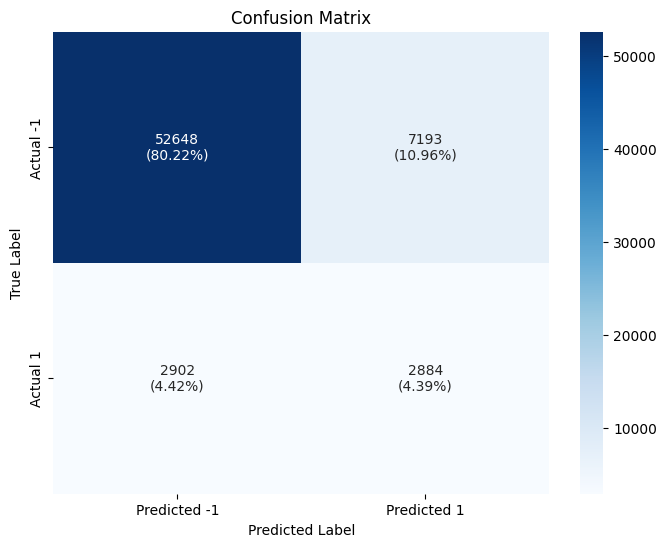

In [3]:
tx_reduced = pca_reduction(tx, 50)
tx_train_split, tx_test_split, y_train_split, y_test_split = split_data(tx_reduced, y_train)
tx_train_split_balanced, y_train_split_balanced = balance_dataset(tx_train_split, y_train_split, 2)
y_train_split_balanced = np.where(y_train_split_balanced == -1, 0, y_train_split_balanced)
predictions = knn_predict_streaming(tx_train_split_balanced, y_train_split_balanced, tx_test_split, 16)
predictions = np.where(predictions == 0, -1, predictions)
cm = create_confusion_matrix(y_test_split, predictions)

_ = cm_visualization(cm)

In [4]:
calculate_f1(cm)

np.float64(0.3636134400806909)

Find optimal values with trial and error

In [6]:
for _ in range(10):
    best_f1 = -1
    best_ratio = None
    best_dim = None
    best_k = None

    for ratio in [2]:
        for dimensions in [45, 47, 50, 53, 55]:
            for k in [13, 14, 15, 16, 17]:
                seed = np.random.randint(1000)
                tx_reduced = pca_reduction(tx, dimensions)
                tx_train_split, tx_test_split, y_train_split, y_test_split = split_data(tx_reduced, y_train, random_state=seed)
                tx_train_split_balanced, y_train_split_balanced = balance_dataset(tx_train_split, y_train_split, ratio, seed=seed)
                y_train_split_balanced = np.where(y_train_split_balanced == -1, 0, y_train_split_balanced)

                predictions = predict_classification_batch(tx_train_split_balanced, y_train_split_balanced, tx_test_split, k)
                predictions = np.where(predictions == 0, -1, predictions)

                f1 = calculate_f1(create_confusion_matrix(y_test_split, predictions))

                if f1 > best_f1:
                    best_f1 = f1
                    best_ratio = ratio
                    best_dim = dimensions
                    best_k = k

    print(f"Best F1: {best_f1:.4f} at ratio={best_ratio}, dimensions={best_dim}, k={best_k}")

Best F1: 0.4119 at ratio=2, dimensions=50, k=16
Best F1: 0.4081 at ratio=2, dimensions=53, k=13
Best F1: 0.4162 at ratio=2, dimensions=53, k=17
Best F1: 0.4227 at ratio=2, dimensions=47, k=14
Best F1: 0.4240 at ratio=2, dimensions=53, k=16
Best F1: 0.4125 at ratio=2, dimensions=55, k=17
Best F1: 0.4125 at ratio=2, dimensions=45, k=16
Best F1: 0.4119 at ratio=2, dimensions=50, k=16
Best F1: 0.4081 at ratio=2, dimensions=53, k=13
Best F1: 0.4162 at ratio=2, dimensions=53, k=17


In [8]:
tx_reduced, X_mean, top_components  = pca_fit(tx, 40)
x_test_preprocessed = preprocess(x_test)
x_test_reduced = pca_transform(x_test_preprocessed, X_mean, top_components)

tx_train_split, y_train_split = tx_reduced, y_train
tx_train_split_balanced, y_train_split_balanced = balance_dataset(tx_train_split, y_train_split, 2)
y_train_split_balanced = np.where(y_train_split_balanced == -1, 0, y_train_split_balanced)
predictions = knn_predict_streaming(tx_train_split_balanced, y_train_split_balanced, x_test_reduced, 15)
predictions = np.where(predictions == 0, -1, predictions)

In [9]:
create_csv_submission(test_ids, predictions, "submission_knn_30_17_components.csv")